<h2 style="text-align: center;">
  Handwritten Digit Recognition: A Comparative Study of kNN and LGBM Models
</h2>
<p>
This project presents a comparative analysis of k-Nearest Neighbours (kNN) and Light Gradient Boosting Machine (LGBM) for handwritten digit classification.
The study includes data exploration, model training, performance evaluation, and a detailed comparison of the strengths and limitations of both algorithms.
</p>

------

<h1 style="display: inline-block; ">
  About Me</h1>

## Wessam Abo Zayed

**Automation Engineering · PLC Programming · Data Analyst** <br>

* Computer Scientist with a focus on Automation Engineering, PLC Programming, and Data Analytics. I combine technical expertise with analytical problem-solving skills to develop practical and efficient solutions for industrial automation systems and data-driven applications.

---

## Kontakt

<div style="text-align: left;">

<table style="margin-left: 0; margin-right: auto;">
  <tr>
    <th style="text-align: center;">Plattform</th>
    <th style="text-align: center;">Link</th>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>E-Mail</strong></td>
    <td style="text-align: left;">
      <a href="mailto:abozayed.wessam@gmail.com">abozayed.wessam@gmail.com</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>LinkedIn</strong></td>
    <td style="text-align: left;">
      <a href="https://www.linkedin.com/in/wessam-abozayed/">linkedin.com/in/wessam-abozayed</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>GitHub</strong></td>
    <td style="text-align: left;">
      <a href="https://github.com/wessam-abo-zayed">github.com/wessam-abo-zayed</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>Tableau Public</strong></td>
    <td style="text-align: left;">
      <a href="https://public.tableau.com/app/profile/wessam3726">public.tableau.com/app/profile/wessam3726</a>
    </td>
  </tr>
</table>

</div>


---------

<h1>Content:</h1>

<ol>
    <li><a href="#python-used-libraries">Python used libraries</a></li>
    <li><a href="#introduction-to-machine-learning">Introduction to Machine Learning</a></li>
    <li><a href="#k-nearest-neighbours-knn">k-Nearest Neighbours (<b>kNN</b>)</a></li>
    <li><a href="#light-gradient-boosting-machine-lgbm">Light Gradient Boosting Machine (<b>LGBM</b>)</a></li>
    <li><a href="#conclusion-results">Conclusion & Results</a></li>
    <li><a href="#references">References</a></li>
</ol>

----------------------------------------------------------

<a id="python-used-libraries"></a>
<h2><center>Libraries</center></h2>
<ol>
<li><h4>numpy(scientific computing package):</h4> It is a Python library that provides a multidimensional array object, various derived objects (such as masked arrays and matrices), and an assortment of routines for fast operations on arrays, including mathematical, logical, shape manipulation, sorting, selecting, I/O, discrete Fourier transforms, basic linear algebra, basic statistical operations, random simulation and much more.</li>
<li><h4>Padas:</h4>Pandas is an open source Python package that is most widely used for data science/data analysis and machine learning tasks. It is built on top of another package named Numpy, which provides support for multi-dimensional arrays. As one of the most popular data wrangling packages, Pandas works well with many other data science modules inside the Python ecosystem, and is typically included in every Python distribution, from those that come with your operating system to commercial vendor distributions like ActiveState’s ActivePython. 
</li>
<li><h4>matplotlib:</h4>Matplotlib is a cross-platform, data visualization and graphical plotting library for Python and its numerical extension NumPy. As such, it offers a viable open source alternative to MATLAB. Developers can also use matplotlib’s APIs (Application Programming Interfaces) to embed plots in GUI applications.</li>
<li><h4>Sklearn:</h4>Open-source ML library for Python. Built on NumPy, SciPy, and Matplotlib. It provides a selection of efficient tools for machine learning and statistical modeling including classification, regression, clustering and dimensionality reduction via a consistence interface in Python.</li>
<ol>

## At first we have to import all last librabries:

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt # A lirary for the visualiazation.
# from sklearn.model_selection import RandomizedSearchCV #  to tune hyperparameters  for ML model
from sklearn import metrics # to measure model preformance ,we used two metrics accuracy and confusion matrix

- We downloaded the data from the given link (MNIST dataset): <a>https://www.kaggle.com/oddrationale/mnist-in-csv</a>

In [2]:
ds_train = pd.read_csv('mnist_train.csv') # read the training data csv file.
ds_test  = pd.read_csv('mnist_test.csv')  # read the testing data csv file.

# let's check the data set (columns & rows):

In [3]:
# the rows in training should be more than testing:
print("Rows:")
print("  Data-set traning rows:",    ds_train.shape[0])
print("  Data-set testing rows:",    ds_test.shape[0] )
print("Columns:")
# the columns should be the same in trainint & testing data-sets
print("  Data-set training columns:",ds_train.shape[1])
print("  Data-set testing columns:", ds_test.shape[1] )

Rows:
  Data-set traning rows: 60000
  Data-set testing rows: 10000
Columns:
  Data-set training columns: 785
  Data-set testing columns: 785


- <b>Conclusion:</b> :we have 785 columns, one column is the label (the  traget variable) that we want to predict and the 784 other columns is our features which stand for image pixels.

In [13]:
ds_train.head(10)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


- Here we can notice the first colm (Label), and we want to remove it fromour data frame, because we have to build the model depends on the given feature.

In [4]:
training_data = ds_train.loc[:,ds_train.columns!="label"] # Choose all columns eccept "label"
testing_data  = ds_test.loc[:,ds_test.columns!="label"]

train_label= ds_train.label
test_label=ds_test.label

print(train_label.head(5)) # Label: is the result or the target that we want to expect.
print("---------------------------------")
print("Label Type is : " , train_label.dtypes)
print("---------------------------------")
print("Features Type is : " ,training_data.dtypes)

0    5
1    0
2    4
3    1
4    9
Name: label, dtype: int64
---------------------------------
Label Type is :  int64
---------------------------------
Features Type is :  1x1      int64
1x2      int64
1x3      int64
1x4      int64
1x5      int64
         ...  
28x24    int64
28x25    int64
28x26    int64
28x27    int64
28x28    int64
Length: 784, dtype: object


- Let's use matplot to show some samples:

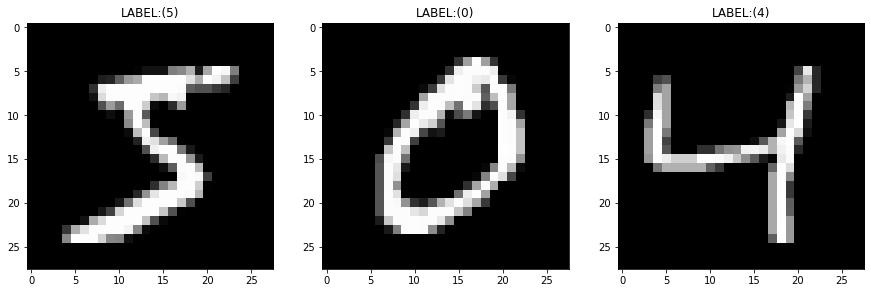

In [15]:
plt.figure(figsize=(15,5))
for index, (image,label) in enumerate(zip(training_data[:3].values, train_label[:3])):
    plt.subplot(1, 3, index+1)
    plt.imshow(np.reshape(image, (28,28)), cmap="gray")
    plt.title("LABEL:(%s)" % label)

-------------------

<a id="introduction-to-machine-learning"></a>
## What is Machine Learning?

- Machine learning is a method of data analysis that automates analytical model building. It is a branch of artificial intelligence based on the idea that systems can learn from data, identify patterns and make decisions with minimal human intervention.

 <img src="images/ML_thinking.jpg">

- Machine learning is an important component of the growing field of data science. Through the use of statistical methods, algorithms are trained to make classifications or predictions, uncovering key insights within data mining projects. These insights subsequently drive decision making within applications and businesses, ideally impacting key growth metrics. As big data continues to expand and grow, the market demand for data scientists will increase, requiring them to assist in the identification of the most relevant business questions and subsequently the data to answer them.
 <img src="images/ML.png">

<a id="k-nearest-neighbours-knn"></a>
<h1> K-Nearest Neighbours(kNN):</h1>

-  K-nearest neighbors (KNN) algorithm is a type of supervised ML algorithm which can be used for both classification as well as regression predictive problems.(However, it is mainly used for classification predictive problems in industry).

- There are three categories of learning algorithms:  
1. <b>Lazy learning algorithm − KNN</b>: is a lazy learning algorithm because it does not have a specialized training phase or model and uses all the data for training while classification.

2. <b>Non-parametric learning algorithm − KNN</b>: is also a non-parametric learning algorithm because it doesn’t assume anything about the underlying data.

3. <b>Eager learning algorithm - Eager learners</b>: when given a set of training tuples, will construct a generalization model before receiving new (e.g., test) tuples to classify.
        
<h3> KNN Algorithm:</h3>
- K-nearest neighbors (KNN) algorithm uses ‘feature similarity’ to predict the values of new data points which further means that the new data point will be assigned a value based on how closely it matches the points in the training set. 

- We can understand its working with the help of following steps:
<ol>
    <li>For implementing any algorithm, we need dataset. So during the first step of KNN, we must <b>load the training as well as test data</b>.</li>
    <li>Next, we need to choose the value of K i.e. the nearest data points. K can be any integer.</li>
    <li>For each point in the test data do the following:</li>
    <ol>
        <li>Calculate the distance between test data and each row of training data with the help of any of the method
             namely: <b>Euclidean, Manhattan or Hamming distance</b>. 
        (The most commonly used method to calculate distance is <b><font color='red'>Euclidean</font></b>).</li> 
        <li>Now, based on the distance value, sort them in ascending order.</li>
        <li>Next, it will choose the top K rows from the sorted array.</li>
        <li>Now, it will assign a class to the test point based on most frequent class of these row</li>
        <li>End.</li>
    </ol>
</ol>     
    


 <img src="images/knn.png">/

<h3>Example:</h3>

- The following is an example to understand the concept of K and working of KNN algorithm, Suppose we have a dataset which can be plotted as follows:
<img src="images/Example_pic1.png">


- Now, we need to classify new data point with black dot (at point 60,60) into blue or red class. We are assuming K = 3 i.e. it would find three nearest data points. It is shown in the following diagram:
<img src="images/Example_pic2.png">


- We can see in the beside diagram the three nearest neighbors of the data point with black dot. Among those three, two of them lies in Red class hence the black dot will also be assigned in red class.

--------

- <h3>KNN: </h3>
* <h3>PROS:</h3>
<ul>
<li>Quick calculation time.</li>
<li>Simple algorithm – to interpret.</li>
<li>Versatile – useful for regression and classification. </li>
<li>High accuracy – you do not need to compare with better-supervised learning models.</li>
<li>No assumptions about data – no need to make additional assumptions, tune several parameters, or build a model. This makes it crucial in nonlinear data case.  </li>
</ul>

* <h3>CONS:</h3>
<ul>
<li>Accuracy depends on the quality of the data</li>
<li>With large data, the prediction stage might be slow.</li>
<li>K is selected from database closest to the new sample.</li>
<li>KNN makes predictions using the similarity between an input sample and each training instance.</li>
</ul>

* <h3> KNN parameters:</h3>
<ul>
    <li><b><font color='green'>n_neighborsint</font></b>: (int , default=5)</li>
   Number of neighbors to use by default for kneighbors queries. 
    <li><b><font color='green'>weights</font></b>:  ({'uniform', 'distance'}default='uniform')</li>
   Weight function used in prediction. Possible values:
    <ul>
        <li><b>'uniform'</b>: uniform weights. All points in each neighborhood are weighted equally.</li>
        <li><b>'distance'</b>: weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.</li>
        <li><b>[callable]</b>: a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.</li>
    </ul>
    
    <li><b><font color='green'>Algorithm</font></b>:  ({'auto', 'ball_tree', 'kd_tree', 'brute'} , default='auto')</li>
   Algorithm used to compute the nearest neighbors:
    <ul>
        <li>'ball_tree': will use BallTree</li>
        <li>'kd_tree':   will use KDTree</li>
        <li>'brute':     will use a brute-force search.</li>
        <li>'auto':      will attempt to decide the most appropriate algorithm based on the values passed to fit method.</li>
    </ul>
    <li><b><font color='green'>leaf_sizeint</font></b>:  (int , default=30)</li>
    Leaf size passed to BallTree or KDTree. This can affect the speed of the construction and query, as well as the memory required to store the tree. The optimal value depends on the nature of the problem.
    <li><b><font color='green'>P</font></b>:  (int , default=2)</li>
    Power parameter for the Minkowski metric. When p = 1, this is equivalent to using manhattan_distance (l1), and euclidean_distance (l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.
    <li><b><font color='green'>metric</font></b>:  (str , default='minkowski')</li>
    Metric to use for distance computation. Default is “minkowski”, which results in the standard Euclidean distance when p = 2. See the documentation of scipy.spatial.distance and the metrics listed in distance_metrics for valid metric values.
    <li><b><font color='green'>metric_params</font></b>:  (dict , default=None)</li>
    Additional keyword arguments for the metric function.
    <li><b><font color='green'>metric</font></b>:  (int , default=None)</li>
    The number of parallel jobs to run for neighbors search. None means 1 unless in a joblib.parallel_backend context. -1 means using all processors. 


- <b>Apply KNN Model:</b>

In [77]:
from sklearn.neighbors import KNeighborsClassifier # Import the model from sklearn library.

In [85]:
print("Label Data is:\n ",train_label)
print("--------------------------------")
print("Training Features is:\n",training_data)

Label Data is:
  0        5
1        0
2        4
3        1
4        9
        ..
59995    8
59996    3
59997    5
59998    6
59999    8
Name: label, Length: 60000, dtype: int64
--------------------------------
Training Features is:
        1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  1x10  ...  28x19  28x20  \
0        0    0    0    0    0    0    0    0    0     0  ...      0      0   
1        0    0    0    0    0    0    0    0    0     0  ...      0      0   
2        0    0    0    0    0    0    0    0    0     0  ...      0      0   
3        0    0    0    0    0    0    0    0    0     0  ...      0      0   
4        0    0    0    0    0    0    0    0    0     0  ...      0      0   
...    ...  ...  ...  ...  ...  ...  ...  ...  ...   ...  ...    ...    ...   
59995    0    0    0    0    0    0    0    0    0     0  ...      0      0   
59996    0    0    0    0    0    0    0    0    0     0  ...      0      0   
59997    0    0    0    0    0    0    0    0    0    

# - Fit the model with data feature:

In [89]:
# Build the model:
Knn_Model = KNeighborsClassifier(n_neighbors=3,
                               weights= "uniform",
                               algorithm = "ball_tree",
                               leaf_size = 35,
                               n_jobs = -1)

In [91]:
# Fit the model:
Knn_Model.fit(training_data,train_label)

KNeighborsClassifier(algorithm='ball_tree', leaf_size=35, n_jobs=-1,
                     n_neighbors=3)

In [101]:
predicts = Knn_Model.predict(testing_data)

In [102]:
accuracy_1 = metrics.accuracy_score(test_label,predicts)
print("The accuricy of KNN Model is: ", accuracy_1*100,"% regearding these model parameters.")

The accuricy of KNN Model is:  97.05 % regearding these model parameters.


# - KNN - Confusion matrix:

In [105]:
CM = metrics.confusion_matrix(test_label, predicts)

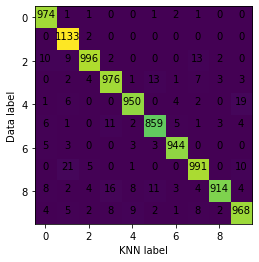

In [124]:
plt.imshow(CM)
plt.xlabel('KNN label', size = 10)
plt.ylabel('Data label', size = 10)
width, height = CM.shape
for x in range(width):
    for y in range(height):
        plt.annotate(str(CM[x][y]), xy=(y, x), horizontalalignment='center')

-------------------------- 

<a id="light-gradient-boosting-machine-lgbm"></a>
# <h1>- Light Gradient Boosting Machine (LGBM):</h1>: 

- <h3> Gradient Boosting Decision tree(GBDT): </h3>
It's a very popular machine learning algorithm that has effective implementations like XGBoost and many optimization techniques are actually adopted from this algorithm. <br>
The efficiency and scalability of the model are not quite up to the mark when there are more features in the data. For this specific behavior, the major reason is that each feature should scan all the various data instances to make an estimate of all the possible split points which is very time-consuming and tedious.
<img src="images/LGBM.jpg">
<br>
To solve this problem, The LGBM or Light Gradient Boosting Model is used

- <h3>What is LGBM? </h3>
It's a gradient boosting framework based on decision trees to increases the efficiency of the model and reduces memory usage. <br>
It uses two novel techniques: <b>Gradient-based One Side Sampling</b> and <b>Exclusive Feature Bundling (EFB)</b> which fulfills the limitations of histogram-based algorithm that is primarily used in all GBDT (Gradient Boosting Decision Tree) frameworks. The two techniques of GOSS and EFB described below form the characteristics of LightGBM Algorithm. They comprise together to make the model work efficiently and provide it a cutting edge over other GBDT frameworks.
<img src="images/LGBM VS XGBoost.png">

- <h3> How LightGBM works? </h3>
1- LightGBM implements a conventional Gradient Boosting Decision Tree (GBDT) algorithm with the addition of two novel techniques: Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB). These techniques are designed to significantly improve the efficiency and scalability of GBDT.<br>
2- The LightGBM algorithm performs well in machine learning competitions because of its robust handling of a variety of data types, relationships, distributions, and the diversity of hyperparameters that you can fine-tune. You can use LightGBM for regression, classification (binary and multiclass), and ranking problems.

- <b>Why Light GBM is gaining extreme popularity?</b><br>
The size of data is increasing day by day and it is becoming difficult for traditional data science algorithms to give faster results. Light GBM is prefixed as ‘Light’ because of its high speed. Light GBM can handle the large size of data and takes lower memory to run. Another reason of why Light GBM is popular is because it focuses on accuracy of results. LGBM also supports GPU learning and thus data scientists are widely using LGBM for data science application development.

- <b>Can we use Light GBM everywhere?</b><br>
No, it is not advisable to use LGBM on small datasets. Light GBM is sensitive to overfitting and can easily overfit small data. Their is no threshold on the number of rows but my experience suggests me to use it only for data with 10,000+ rows

- <b>Maths behind LGBM:</b><br>
We use a concept known as verdict trees so that we can cram a function like for example, from the input space X, towards the gradient space G. A training set with the instances like x1,x2 and up to xn is assumed where each element is a vector with s dimensions in the space X. In each of the restatements of a gradient boosting, all the negative gradients of a loss function with respect towards the output model are denoted as g1, g2, and up to gn. The decision tree actually divides each and every node at the most revealing feature, it also gives rise to the largest evidence gain. In this type of model, the data improvement can be measured by the variance after segregating. It can be represented by the following formula :<br><br>
<center>"Y=Base_tree(X)-lr*Tree1(X)-lr*Tree2(X)-lr*Tree3(X)"</center><br><br>
Explanation, Let O be a training dataset on a fixed node of a decision tree and then the variance gain of dividing measure j at a point d for a node is defined as :<br>
<img src="images/LGBM Formula 1.png"  width="400" ><br><br>
Gradient One-Sided Sampling or GOSS utilizes every instance with a larger gradient and does the task of random sampling on the various instances with the small gradients. The training dataset is given by the notation of O for each particular node of the Decision tree. The variance gain of j or the dividing measure at the point d for the node is given by :
<img src="images/LBGM Formula 2.png"  width="400" ><br><br>
This is achieved by the method of GOSS in LightGBM models.


-  <h3>LDBM Parameters:</h3>
<ol>
    <li><font color="green"><b>Control Parameters:</b></font></li>
    <ol>
        <li><font color="gray"><b>max_depth:</b></font></li>
        It describes the maximum depth of tree. This parameter is used to handle model overfitting. Any time you feel that your model is overfitted, my first advice will be to lower max_depth.
        <li><font color="gray"><b>min_data_in_leaf :</b></font><font color="green">(default= 20, used to deal over fitting)</font></li>
        Minimum number of the records a leaf may have.
        <li><font color="gray"><b>feature_fraction: </b></font></li>
        Random percentage of parameters selection in each iteration for building trees.
        <li><font color="gray"><b>bagging_fraction:</b></font> <font color="green">(Used for speed up the training and avoid overfitting)</font>  </li>
        specifies the fraction of data to be used for each iteration.
        <li><font color="gray"><b>early_stopping_round:</b></font> <font color="green">(Reduce excessive iterations)</font>  </li>
        Model will stop training if one metric of one validation data doesn’t improve in last early_stopping_round rounds (reduce iteration).        
        <li><font color="gray"><b>lambda:</b></font> <font color="green">(Range: 0-1)</font>  </li>
         Specifies regularization
        <li><font color="gray"><b>min_gain_to_split:</b></font></li>
       It's the minimum gain to make a split (to control number of useful splits in tree).
        <li><font color="gray"><b>max_cat_group:</b></font> <font color="green">(default:64)</font> </li>
        LightGBM merges them into 'max_cat_group' groups, When the number of category is large, finding the split point on it is easily over-fitting.
    </ol>
    <li><font color="green"><b>Core Parameters:</b></font></li>
    <ol>
    <li><font color="gray"><b>Task:</b></font> <font color="green">(Train or Predict.)</font> </li>
        Specifies the task.
    <li><font color="gray"><b>application:</b></font><font color="green">(Default:regression)</font></li>
        Determine whether the model is a regression problem or classification problem. <br>
         1- regression: for regression. <br>
         2- binary: for binary classification. <br>
         3- multiclass: for multiclass classification problem. <br>
    <li><font color="gray"><b>boosting:</b></font><font color="green">(Default:gdbt)</font> </li>
        Type of algorithm: <br>
        1- gbdt: traditional Gradient Boosting Decision Tree. <br>
        2- rf: random forest. <br>
        3- dart: Dropouts meet Multiple Additive Regression Trees. <br>
        4- goss: Gradient-based One-Side Sampling. <br>
    <li><font color="gray"><b>num_boost_round:</b></font> </li>
        Number of boosting iterations.
    <li><font color="gray"><b>learning_rate:</b></font> </li>
         Impact of each tree on the final outcome. Typical values: 0.1, 0.001, 0.003…
    <li><font color="gray"><b>num_leaves:</b></font><font color="green">(Default:31)</font> </li>
        Number of leaves in full tree.
    <li><font color="gray"><b>device:</b></font><font color="green">(Default:cpu)</font> </li>
        We can use also gpu.    
 </ol>  
    <li><font color="green"><b>Metric parameter:</b></font></li>
     <ol>
         <li><font color="gray"><b>metric:</b></font> </li>
         specifies loss for model building. Below are few general losses for regression and classification.<br>
         1- mae: mean absolute error.<br>
         2- mse: mean squared error.<br>
         3- binary_logloss: loss for binary classification.<br>
         4- multi_logloss: loss for multi classification.<br>
      </ol>
   <li><font color="green"><b>IO parameter:</b></font></li>
    <ol>
        <li><font color="gray"><b>max_bin:</b></font></li>
        The maximum number of bin that feature value will bucket in.
         <li><font color="gray"><b>categorical_feature:</b></font></li>
        It's the index of categorical features. (If categorical_features=0,1,2 then column 0, column 1 and column 2 are categorical variables.)
         <li><font color="gray"><b>ignore_column:</b></font></li>
        same as categorical_features just instead of considering specific columns as categorical, it will completely ignore them.
         <li><font color="gray"><b>save_binary:</b></font></li>
        - (True) Specifying parameter true will save the dataset to binary file, this binary file will speed your data reading time for the next time.
       
    </ol>

</ol>

- <h3>PROS:</h3>
<ul>
<li> Faster training speed and higher efficiency.</li>
<li> Lower memory usage</li>
<li>Better accuracy.</li>
<li>Support of parallel and GPU learning. </li>
<li> Capable of handling large-scale data. </li>
</ul>

- <h3>CONS:</h3>
<ul>
    <li><font color="green"> <b>Overfitting:</b> </font> </li>
    Light GBM split the tree leaf-wise which can lead to overfitting as it produces much complex trees.
<li><font color="green"> <b>Compatibility with Datasets::</b> </font>  </li>
    Light GBM is sensitive to overfitting and thus can easily overfit small data.
</ul>

- <h2>LGBM implementation </h2>

In [32]:
# Install the library
# !pip install lightgbm

In [54]:
# import the library:
import lightgbm as lgb

In [55]:
d_train = lgb.Dataset(training_data, label=train_label)

In [56]:
#setting up the parameters
params={}
params['learning_rate']=0.03
params['boosting_type']='gbdt'  #GradientBoostingDecisionTree
params['objective']='multiclass' #Multi-class target feature
params['metric']='multi_logloss' #metric for multi-class
params['max_depth']=10
params['num_class']=10 #no.of unique values in the target class not inclusive of the end value

#training the model
clf = lgb.train(params,d_train,100)  #training the model on 100 epocs
#prediction on the test dataset
y_pred_1 = clf.predict(testing_data)
#printing the predictions
y_pred_1

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.998641 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 109606
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 629
[LightGBM] [Info] Start training from score -2.315501
[LightGBM] [Info] Start training from score -2.185988
[LightGBM] [Info] Start training from score -2.309610
[LightGBM] [Info] Start training from score -2.280987
[LightGBM] [Info] Start training from score -2.329271
[LightGBM] [Info] Start training from score -2.404064
[LightGBM] [Info] Start training from score -2.316346
[LightGBM] [Info] Start training from score -2.259366
[LightGBM] [I

array([[1.26637964e-03, 1.12546657e-03, 1.86618852e-03, ...,
        9.82749692e-01, 1.56824594e-03, 3.08866262e-03],
       [1.14658237e-02, 3.26446449e-03, 9.11375126e-01, ...,
        1.30254398e-03, 4.47412639e-03, 1.46848018e-03],
       [9.30864656e-04, 9.86461323e-01, 1.54336954e-03, ...,
        1.36983829e-03, 1.85290500e-03, 1.23554083e-03],
       ...,
       [1.20358289e-03, 1.36140582e-03, 1.79693740e-03, ...,
        2.94774446e-03, 1.09880685e-02, 1.22512098e-02],
       [3.00468925e-03, 4.34493356e-03, 2.86320508e-03, ...,
        2.69224696e-03, 8.22263530e-02, 4.30912630e-03],
       [1.45405140e-03, 1.02664704e-03, 3.20694406e-03, ...,
        1.09750608e-03, 1.73345735e-03, 1.12518107e-03]])

In [57]:
#argmax() method 
y_pred_1 = [np.argmax(line) for line in y_pred_1]
print(y_pred_1[0:10])

[7, 2, 1, 0, 4, 1, 4, 9, 5, 9]


In [58]:
# using precision score for error metrics
from sklearn.metrics import precision_score
precision_score(y_pred_1,test_label,average=None).mean()

0.9600252990801103

In [59]:
from sklearn import metrics # to measure model preformance ,we used two metrics accuracy and confusion matrix
accuracy_1 = metrics.accuracy_score(test_label,y_pred_1)
print("The accuricy of lgbm Model is: ", accuracy_1*100,"% regearding these model parameters.")

The accuricy of lgbm Model is:  96.04 % regearding these model parameters.


- <h3> Let's try another parameters and check the accuracy again:

In [61]:
params1 = {}
params1['learning_rate'] = 0.003
params1['objective'] = 'multiclass'
params1['metric'] = 'multi_logloss'
params1['sub_feature'] = 0.5
params1['num_leaves'] = 10
params1['min_data'] = 50
params1['application'] = "multiclass"
params1['max_depth'] = 2
params1['num_class']=10
############################################
#training the model
clf1 = lgb.train(params1,d_train,100)  #training the model on 100 epocs
#prediction on the test dataset
y_pred_11 = clf.predict(testing_data)
#printing the predictions
y_pred_11

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] objective is set=multiclass, application=multiclass will be ignored. Current value: objective=multiclass
[LightGBM] [Warning] objective is set=multiclass, application=multiclass will be ignored. Current value: objective=multiclass
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.505539 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 109606
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 629
[LightGBM] [Info] Start training from score -2.315501
[LightGBM] [Info] Start training from score -2.185988
[LightGBM] [Info] Start training from score -2.309610
[LightGBM] [Info] Start training from score -2.280987
[LightGBM] [Info] Start training from score

array([[1.26637964e-03, 1.12546657e-03, 1.86618852e-03, ...,
        9.82749692e-01, 1.56824594e-03, 3.08866262e-03],
       [1.14658237e-02, 3.26446449e-03, 9.11375126e-01, ...,
        1.30254398e-03, 4.47412639e-03, 1.46848018e-03],
       [9.30864656e-04, 9.86461323e-01, 1.54336954e-03, ...,
        1.36983829e-03, 1.85290500e-03, 1.23554083e-03],
       ...,
       [1.20358289e-03, 1.36140582e-03, 1.79693740e-03, ...,
        2.94774446e-03, 1.09880685e-02, 1.22512098e-02],
       [3.00468925e-03, 4.34493356e-03, 2.86320508e-03, ...,
        2.69224696e-03, 8.22263530e-02, 4.30912630e-03],
       [1.45405140e-03, 1.02664704e-03, 3.20694406e-03, ...,
        1.09750608e-03, 1.73345735e-03, 1.12518107e-03]])

In [62]:
#argmax() method 
y_pred_11 = [np.argmax(i) for i in y_pred_11]
print(y_pred_11[0:10])

[7, 2, 1, 0, 4, 1, 4, 9, 5, 9]


In [63]:
# using precision score for error metrics
from sklearn.metrics import precision_score
precision_score(y_pred_11,test_label,average=None).mean()

0.9600252990801103

In [64]:
from sklearn import metrics # to measure model preformance ,we used two metrics accuracy and confusion matrix
accuracy_1 = metrics.accuracy_score(test_label,y_pred_11)
print("The accuricy of lgbm 1 Model is: ", accuracy_1*100,"% regearding these model parameters.")

The accuricy of lgbm 1 Model is:  96.04 % regearding these model parameters.


- There is no deffirance in the accueacy, but the training time became faster in the second one because we reduce the 'max_depth' to "2".

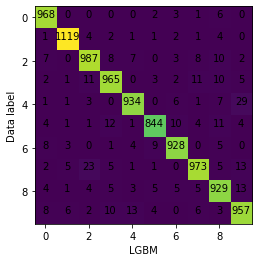

In [66]:
CM = metrics.confusion_matrix(test_label, y_pred_11)
plt.imshow(CM)
plt.xlabel('LGBM', size = 10)
plt.ylabel('Data label', size = 10)
width, height = CM.shape
for x in range(width):
    for y in range(height):
        plt.annotate(str(CM[x][y]), xy=(y, x), horizontalalignment='center')

<a id="conclusion-results"></a>
## conclusion-results:<br>
- ## comparing the preforamnce of the 2 models using bar plots:

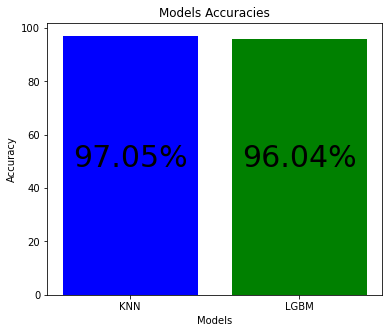

In [38]:
# function to add value labels
def addlabels(x,y):
    for i in range(len(x)):
        plt.text(i, y[i]//2, str(y[i])+"%", ha = 'center',fontsize=30)
models = ["KNN", "LGBM"]
acc = [97.05, 96.04]
plt.figure(figsize = (6,5))
# making the bar chart on the data
plt.bar(models[0], acc[0], color ='blue')
plt.bar(models[1], acc[1], color ='green')
# calling the function to add value labels
addlabels(models, acc)
# giving title to the plot
plt.title("Models Accuracies")
# giving X and Y labels
plt.xlabel("Models")
plt.ylabel("Accuracy")

# visualizing the plotssd
plt.show()

----------

<a id="references"></a>
- <h3> References:</h3>
<ul>
    <li> <a> https://numpy.org/doc/stable/user/whatisnumpy.html</a></li>
    <li> <a> https://www.activestate.com/resources/quick-reads/what-is-pandas-in-python-everything-you-need-to-know/
</a></li>
    <li> <a> https://www.codecademy.com/article/scikit-learn</a></li>
    <li><a>https://www.sas.com/en_ae/insights/analytics/machine-learning.html</a></li>
    <li><a>https://www.mygreatlearning.com/blog/knn-algorithm-introduction/</a></li>
    <li> <a> https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html </a></li>
    
    <li><a>https://docs.aws.amazon.com/sagemaker/latest/dg/lightgbm-HowItWorks.html</a></li>
    <li><a>https://medium.com/@pushkarmandot/https-medium-com-pushkarmandot-what-is-lightgbm-how-to-implement-it-how-to-fine-tune-the-parameters-60347819b7fc#:~:text=Light%20GBM%20grows%20tree%20vertically,than%20a%20level-wise%20algorithm.</a></li>
    <li><a>https://www.kdnuggets.com/2020/06/lightgbm-gradient-boosting-decision-tree.html</a></li>
    
</ul>